# A3 – Linear Discriminant Analysis (LDA) From Scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# Example two-class dataset
# Rows = samples, columns = features
X = np.array([
    [1.0, 2.0],
    [1.5, 1.8],
    [2.0, 2.2],
    [2.2, 1.9],
    [5.0, 8.0],
    [5.5, 8.5],
    [6.0, 8.0],
    [6.5, 8.8]
])

# Class labels
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nX =")
print(X)
print("\ny =", y)

X shape: (8, 2)
y shape: (8,)

X =
[[1.  2. ]
 [1.5 1.8]
 [2.  2.2]
 [2.2 1.9]
 [5.  8. ]
 [5.5 8.5]
 [6.  8. ]
 [6.5 8.8]]

y = [0 0 0 0 1 1 1 1]


## 1. Compute class-wise means and overall mean

For each class, calculate its mean vector. The overall mean is calculated using all samples.

- **Class mean:** center of a particular class
- **Overall mean:** center of the complete dataset

In [2]:
classes = np.unique(y)

# Class-wise means
class_means = {}

for cls in classes:
    class_means[cls] = np.mean(X[y == cls], axis=0)

# Overall mean
overall_mean = np.mean(X, axis=0)

print("Class-wise means:")
for cls, mean in class_means.items():
    print(f"Class {cls}: {mean}")

print("\nOverall mean:")
print(overall_mean)

Class-wise means:
Class 0: [1.675 1.975]
Class 1: [5.75  8.325]

Overall mean:
[3.7125 5.15  ]


## 2. Construct the Within-Class Scatter Matrix (SW)

**SW measures variation within each class.**

In [3]:
SW = np.zeros((X.shape[1], X.shape[1]))

for cls in classes:
    X_class = X[y == cls]
    centered = X_class - class_means[cls]
    SW += centered.T @ centered

print("SW =")
print(SW)

SW =
[[2.1175 0.5225]
 [0.5225 0.555 ]]


## 3. Construct the Between-Class Scatter Matrix (SB)

**SB measures variation between the class means.**

In [4]:
SB = np.zeros((X.shape[1], X.shape[1]))

for cls in classes:
    X_class = X[y == cls]
    n_class = X_class.shape[0]
    mean_diff = (class_means[cls] - overall_mean).reshape(-1, 1)
    SB += n_class * (mean_diff @ mean_diff.T)

print("SB =")
print(SB)

SB =
[[33.2112 51.7525]
 [51.7525 80.645 ]]


## 4. Solve the eigenvalue problem for SW⁻¹SB


In [5]:
# Compute SW inverse (pseudo-inverse is more stable if SW is singular)
SW_inv = np.linalg.pinv(SW)

# Matrix for the generalized eigenvalue problem
A = SW_inv @ SB

# Compute eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(A)

# Convert numerical complex values to real values when appropriate
eigvals = np.real(eigvals)
eigvecs = np.real(eigvecs)

print("Eigenvalues:")
print(eigvals)

print("\nEigenvectors:")
print(eigvecs)

Eigenvalues:
[  0.     149.7625]

Eigenvectors:
[[-0.8416  0.0929]
 [ 0.5401 -0.9957]]


## 5. Select the top k discriminant vectors

In [6]:
# Sort eigenvectors by descending eigenvalues
sorted_indices = np.argsort(eigvals)[::-1]

eigvals_sorted = eigvals[sorted_indices]
eigvecs_sorted = eigvecs[:, sorted_indices]

# Maximum possible number of LDA components
max_components = min(X.shape[1], len(classes) - 1)

# Choose k components
k = max_components

# Selected discriminant vectors
W = eigvecs_sorted[:, :k]

print("Sorted eigenvalues:")
print(eigvals_sorted)

print("\nSelected number of components:", k)
print("\nSelected discriminant vectors W:")
print(W)

Sorted eigenvalues:
[149.7625   0.    ]

Selected number of components: 1

Selected discriminant vectors W:
[[ 0.0929]
 [-0.9957]]


## 6. Project the dataset onto the new lower-dimensional subspace

In [7]:
X_lda = X @ W

print("Reduced-dimensional feature matrix:")
print(X_lda)

print("\nOriginal shape:", X.shape)
print("Reduced shape:", X_lda.shape)

Reduced-dimensional feature matrix:
[[-1.8984]
 [-1.6528]
 [-2.0046]
 [-1.6873]
 [-7.5007]
 [-7.9521]
 [-7.4078]
 [-8.1579]]

Original shape: (8, 2)
Reduced shape: (8, 1)


## 7. Visualize the transformed data

For a two-class dataset and one LDA component, the transformed samples lie on a one-dimensional discriminant axis. We visualize the two classes along that axis.

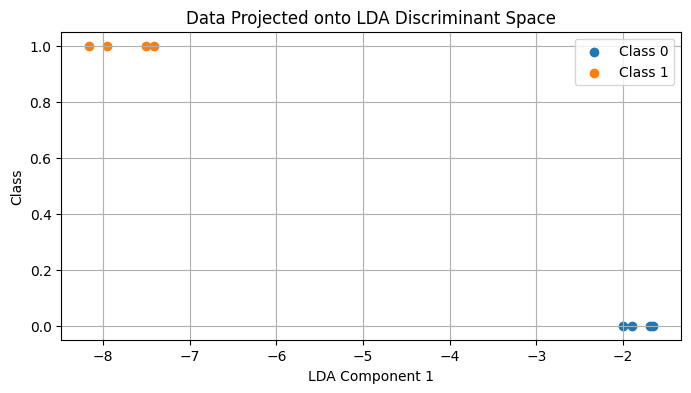

In [8]:
plt.figure(figsize=(8, 4))

for cls in classes:
    values = X_lda[y == cls, 0]
    plt.scatter(
        values,
        np.zeros_like(values) + cls,
        label=f"Class {cls}"
    )

plt.xlabel("LDA Component 1")
plt.ylabel("Class")
plt.title("Data Projected onto LDA Discriminant Space")
plt.legend()
plt.grid(True)
plt.show()

## Conclusion

LDA maximizes class separability by finding directions where:

- **Within-class scatter (SW) is low** → samples from the same class stay close.
- **Between-class scatter (SB) is high** → different class means are far apart.
- **Largest eigenvalues** identify the most discriminative directions.
- The selected eigenvectors form the projection matrix `W`.
- `X @ W` gives the reduced-dimensional LDA representation.

For the practical requirement, this implementation uses only **NumPy for the LDA calculations** and **Matplotlib for visualization**, and does not use a built-in LDA function.